Team 4:


1.   Sadiya Puspo
2.   Sai Padma Sriya Pothula
3.   Adi Mohan



To run the code: please load the datasets:


1.   deliveries.csv
2.   matches.csv



**Importing Necessary Libraries**

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.naive_bayes import GaussianNB, MultinomialNB


**Loading Dataset in Pandas dataframe**

In [2]:
# Load the datasets
deliveries_path = 'deliveries.csv'
matches_path = 'matches.csv'

# Reading the CSV files
deliveries_df = pd.read_csv(deliveries_path)
matches_df = pd.read_csv(matches_path)

# Displaying the first few rows of each dataset
deliveries_df_head = deliveries_df.head()
matches_df_head = matches_df.head()

# Checking the column names and some basic info for both datasets
deliveries_info = deliveries_df.info()
matches_info = matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

**Checking the percentage of missing values for each column**

In [3]:
#Checking for missing values
missing_values = (deliveries_df.isnull().sum()/len(deliveries_df)) * 100

# Print the result
print(missing_values)

match_id             0.000000
inning               0.000000
batting_team         0.000000
bowling_team         0.000000
over                 0.000000
ball                 0.000000
batter               0.000000
bowler               0.000000
non_striker          0.000000
batsman_runs         0.000000
extra_runs           0.000000
total_runs           0.000000
extras_type         94.586463
is_wicket            0.000000
player_dismissed    95.036793
dismissal_kind      95.036793
fielder             96.414993
dtype: float64


The coulmns with missing values are rare cases, for this reason not present in every case. Therefore we will not handle these missing values.

# **Exploratory Data Analysis (EDA)**


EDA 1: Distribution of Total Runs per match

EDA 2: Average Runs per Match



<ipython-input-4-b9cbe34be199>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_runs_per_over.index, y=average_runs_per_over.values, ax=ax[1], palette='viridis')


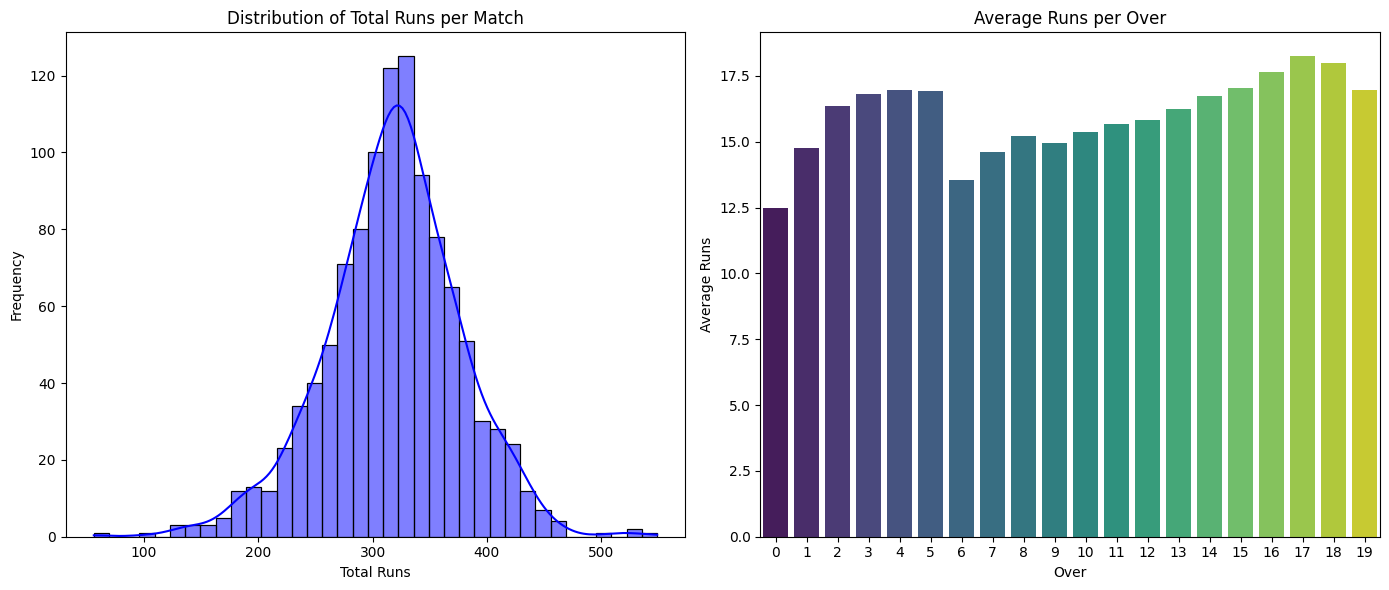

In [4]:
# Calculating total runs per match
total_runs_per_match = deliveries_df.groupby('match_id')['total_runs'].sum()

# Calculating runs per over
runs_per_over = deliveries_df.groupby(['match_id', 'over'])['total_runs'].sum().reset_index()
average_runs_per_over = runs_per_over.groupby('over')['total_runs'].mean()

# Setting up the plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plotting total runs per match
sns.histplot(total_runs_per_match, ax=ax[0], kde=True, color='blue')
ax[0].set_title('Distribution of Total Runs per Match')
ax[0].set_xlabel('Total Runs')
ax[0].set_ylabel('Frequency')

# Plotting runs per over
sns.barplot(x=average_runs_per_over.index, y=average_runs_per_over.values, ax=ax[1], palette='viridis')
ax[1].set_title('Average Runs per Over')
ax[1].set_xlabel('Over')
ax[1].set_ylabel('Average Runs')

plt.tight_layout()
plt.show()




EDA 3: Impact of winning the Toss on Match Outcomes




<ipython-input-5-ae5e68538c91>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_win_effect.index, y=toss_win_effect.values, palette='coolwarm')


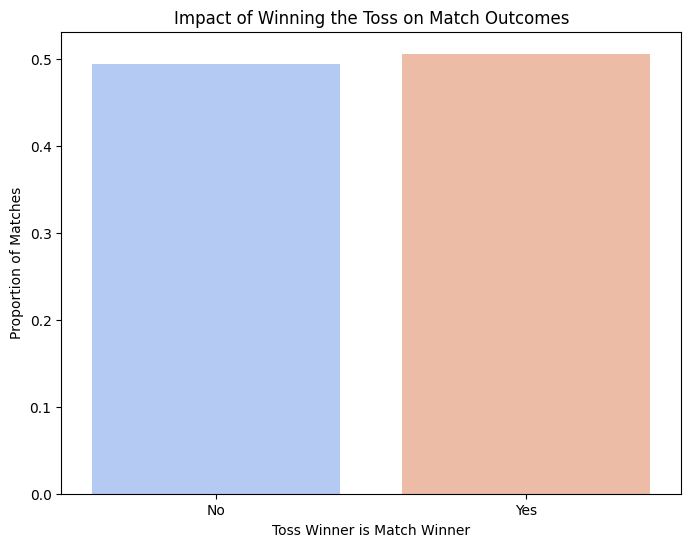

In [5]:
# Determine if the toss winner also won the match
matches_df['toss_winner_is_match_winner'] = (matches_df['toss_winner'] == matches_df['winner'])

# Calculating win rates for toss winning and not winning
toss_win_effect = matches_df.groupby('toss_winner_is_match_winner')['id'].count() / len(matches_df)

# Setting up the plot
plt.figure(figsize=(8, 6))
sns.barplot(x=toss_win_effect.index, y=toss_win_effect.values, palette='coolwarm')
plt.title('Impact of Winning the Toss on Match Outcomes')
plt.xlabel('Toss Winner is Match Winner')
plt.ylabel('Proportion of Matches')
plt.xticks([0, 1], ['No', 'Yes'])  # Set x-tick labels for clarity

plt.show()


EDA 3: Win Proportion: Batting First VS Chasing

<ipython-input-6-656125b04463>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bat_first_win_rate.index, y=bat_first_win_rate.values, palette='coolwarm')


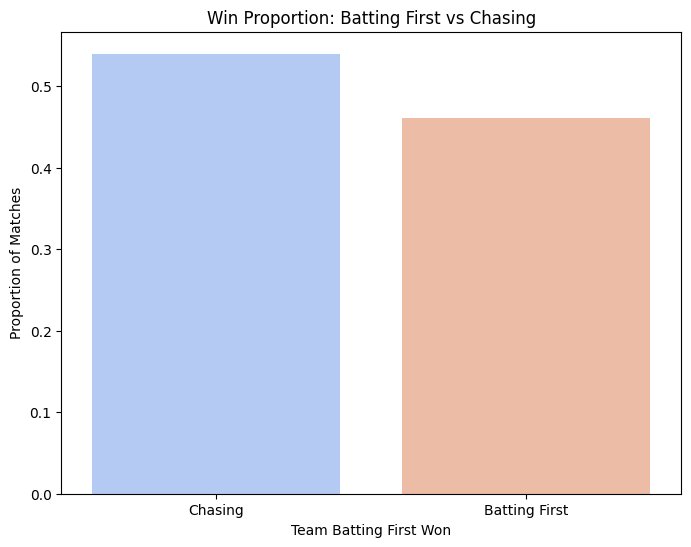

In [6]:
# Determine if the team that batted first won the match
matches_df['bat_first_won'] = (matches_df['toss_decision'] == 'bat') & (matches_df['toss_winner'] == matches_df['winner']) | \
                           (matches_df['toss_decision'] == 'field') & (matches_df['toss_winner'] != matches_df['winner'])

# Calculating win rates for batting first and chasing
bat_first_win_rate = matches_df.groupby('bat_first_won')['id'].count() / len(matches_df)

# Setting up the plot
plt.figure(figsize=(8, 6))
sns.barplot(x=bat_first_win_rate.index, y=bat_first_win_rate.values, palette='coolwarm')
plt.title('Win Proportion: Batting First vs Chasing')
plt.xlabel('Team Batting First Won')
plt.ylabel('Proportion of Matches')
plt.xticks([0, 1], ['Chasing', 'Batting First'])  # Set x-tick labels for clarity

plt.show()


EDA 4: Powerplay Performance and Match Result

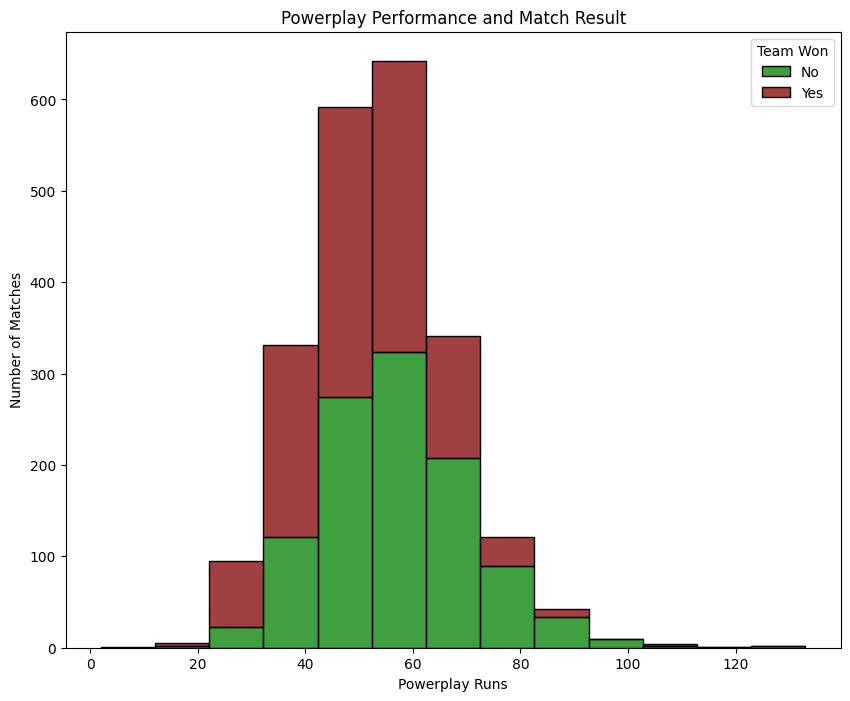

In [7]:
# Filter deliveries for the first 6 overs
powerplay_deliveries = deliveries_df[deliveries_df['over'] <= 6]

# Calculate total runs scored during Powerplay for each match and team
powerplay_stats = powerplay_deliveries.groupby(['match_id', 'batting_team']).agg({'total_runs': 'sum'}).reset_index()
powerplay_stats.rename(columns={'total_runs': 'powerplay_runs'}, inplace=True)

# Merge powerplay performance with match outcomes
powerplay_analysis = pd.merge(powerplay_stats, matches_df, left_on='match_id', right_on='id', how='left')

# Add a column to determine if the batting team during the powerplay is the winner
powerplay_analysis['team_won'] = powerplay_analysis['winner'] == powerplay_analysis['batting_team']

# Visualize the powerplay performance for winning vs losing teams
plt.figure(figsize=(10, 8))
sns.histplot(data=powerplay_analysis, x='powerplay_runs', hue='team_won', binwidth=10, element='bars', stat='count', multiple='stack', palette={True: 'green', False: 'maroon'})
plt.title('Powerplay Performance and Match Result')
plt.xlabel('Powerplay Runs')
plt.ylabel('Number of Matches')
plt.legend(title='Team Won', labels=['No', 'Yes'])
plt.show()


EDA 5: Distribution of Wins by Runs, Wickets, Ties and No Results

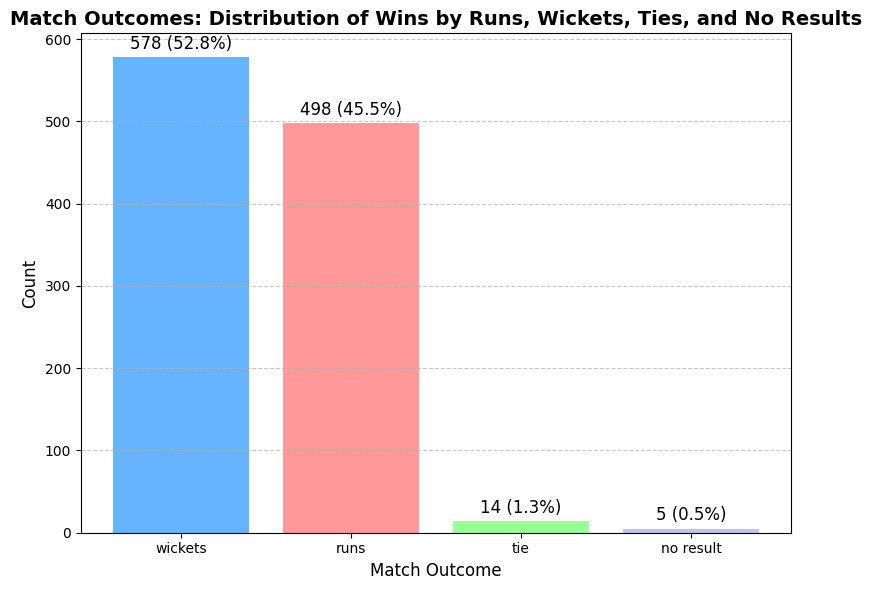

In [8]:
# Match Outcome Summary - Bar Chart
result_counts = matches_df['result'].value_counts()

# Plot the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(result_counts.index, result_counts.values, color=['#66b3ff', '#ff9999', '#99ff99', '#c2c2f0', '#ffb3e6'])

# Add value labels above each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             f'{bar.get_height()} ({bar.get_height() / result_counts.sum() * 100:.1f}%)',
             ha='center', fontsize=12)

# Customize the chart
plt.title('Match Outcomes: Distribution of Wins by Runs, Wickets, Ties, and No Results', fontsize=14, fontweight='bold')
plt.xlabel('Match Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()


EDA 6: Total Wins per team accros  all seasons

EDA 7: Team Performance: WIn per season

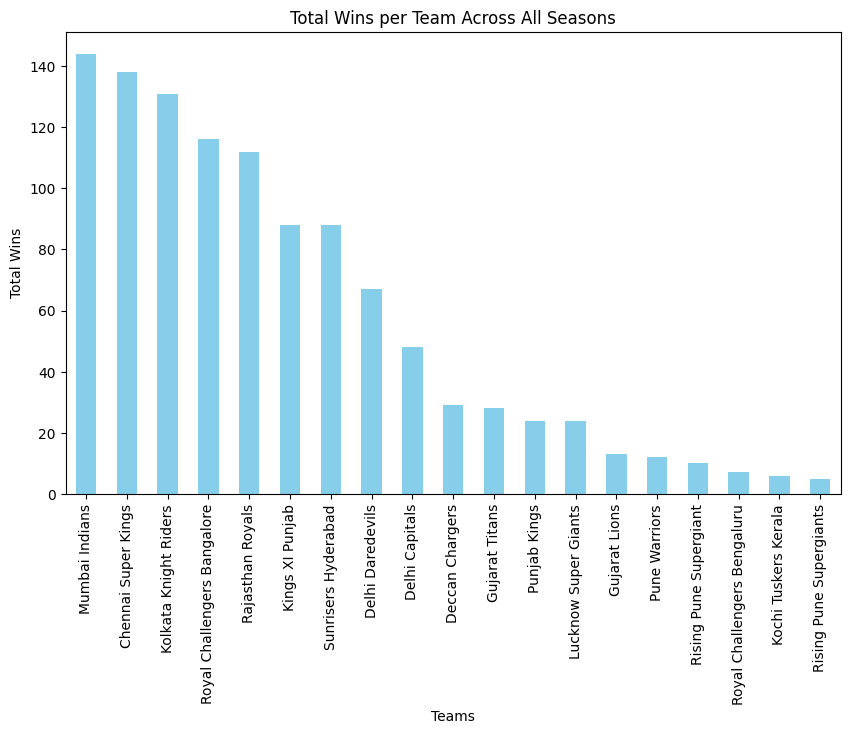

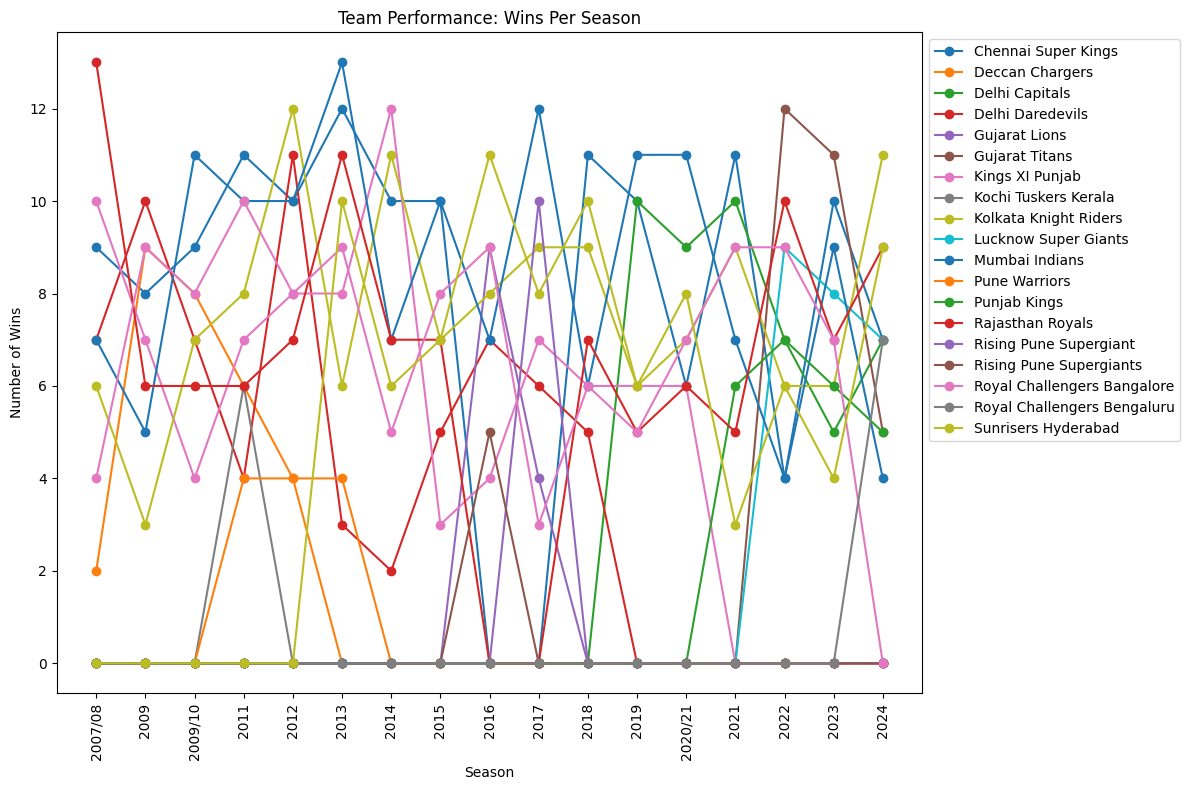

In [11]:
# Team Performance: Wins per Team across Seasons

# Grouping by team and season to get the count of wins per team per season
wins_per_team_season = matches_df.groupby(['season', 'winner']).size().reset_index(name='wins')

# Pivot table to have seasons as columns, teams as rows, and wins as values
wins_pivot = wins_per_team_season.pivot(index='winner', columns='season', values='wins').fillna(0)

# Bar Chart: Total Wins per Team across Seasons
total_wins_per_team = wins_per_team_season.groupby('winner')['wins'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
total_wins_per_team.plot(kind='bar', color='skyblue')
plt.title('Total Wins per Team Across All Seasons')
plt.xlabel('Teams')
plt.ylabel('Total Wins')
plt.xticks(rotation=90)
plt.show()

# Line Chart: Wins per Team across Seasons
plt.figure(figsize=(12, 8))
for team in wins_pivot.index:
    plt.plot(wins_pivot.columns, wins_pivot.loc[team], marker='o', label=team)

plt.title("Team Performance: Wins Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Wins")
plt.xticks(rotation=90)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


# **Research Question 1: Does Winning the Toss Affect Match Outcome?**

**Creating target variabl as per the research question**

In [12]:
# Create target: did the toss winner also win the match?
matches_df['toss_win_match_win'] = matches_df['toss_winner'] == matches_df['winner']

# Define features
features = ['venue', 'toss_winner', 'team1', 'team2']
X = pd.get_dummies(matches_df[features], drop_first=True)  # One-hot encode categorical features
y = matches_df['toss_win_match_win'].astype(int)  # Convert boolean to binary

# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Confirm the sizes of the splits
{
    "Train Size": len(X_train),
    "Validation Size": len(X_val),
    "Test Size": len(X_test),
}


{'Train Size': 657, 'Validation Size': 219, 'Test Size': 219}

**Random Forest with Grid Search**

In [13]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV on training data
grid_search.fit(X_train, y_train)

# Best parameters and estimator
print("Best Parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# Evaluate on validation set
y_val_pred = best_rf_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_rf_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Validation Accuracy: 0.45662100456621
Validation Classification Report:
              precision    recall  f1-score   support

        Loss       0.44      0.51      0.47       104
         Win       0.48      0.41      0.44       115

    accuracy                           0.46       219
   macro avg       0.46      0.46      0.46       219
weighted avg       0.46      0.46      0.46       219

Test Accuracy: 0.4794520547945205
Test Classification Report:
              precision    recall  f1-score   support

        Loss       0.47      0.51      0.49       107
         Win       0.49      0.45      0.47       112

    accuracy                           0.48       219
   macro avg       0.48      0.48      0.48       219
weighted avg       0.48      0.48      0.48       219



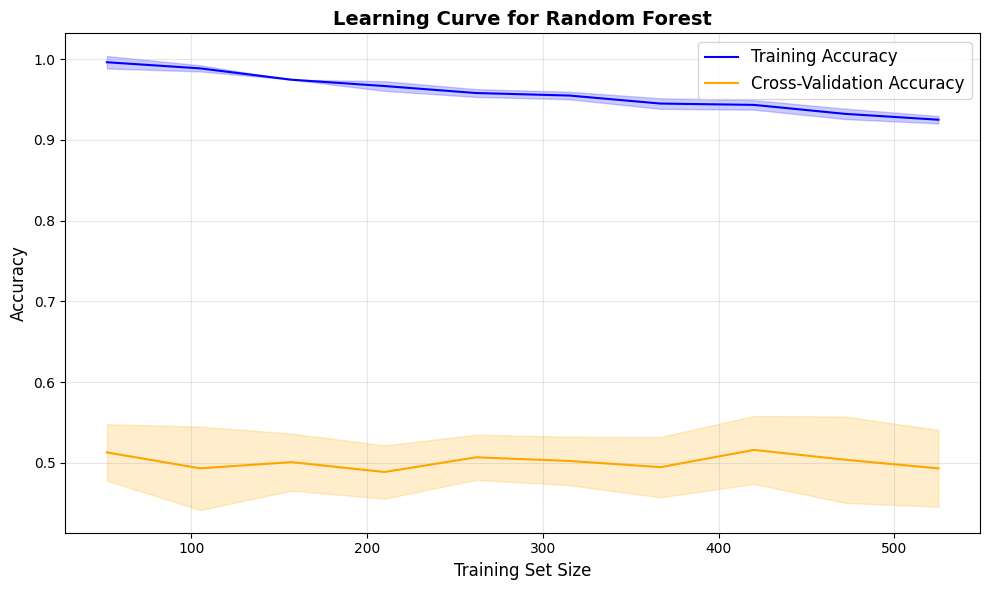

In [16]:
# Learning curve
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=-1
)

# Calculate mean and standard deviation of training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, test_scores_mean, label='Cross-Validation Accuracy', color='orange')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2, color='orange')

# Customize the plot
plt.title('Learning Curve for Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


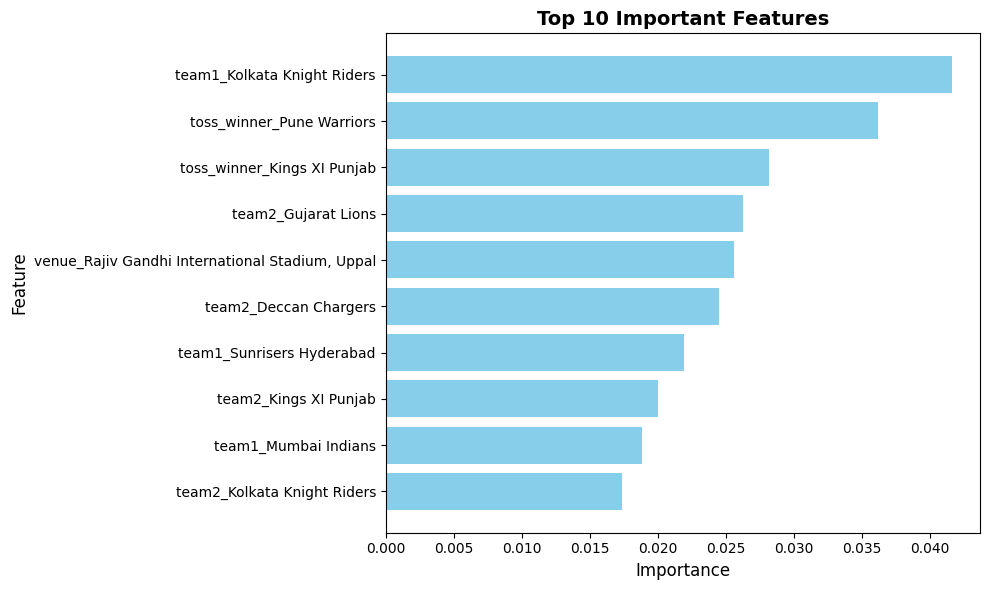

,Feature,Importance
82,team1_Kolkata Knight Riders,0.041602
67,toss_winner_Pune Warriors,0.036216
62,toss_winner_Kings XI Punjab,0.028187
96,team2_Gujarat Lions,0.026297
41,"venue_Rajiv Gandhi International Stadium, Uppal",0.025609
93,team2_Deccan Chargers,0.024480
92,team1_Sunrisers Hyderabad,0.021927
98,team2_Kings XI Punjab,0.019987
84,team1_Mumbai Indians,0.018805
100,team2_Kolkata Knight Riders,0.017357


In [14]:
# Get feature importances
importances = best_rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.title('Top 10 Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

feature_importance_df.head(10)

Logistic Regression with Grid Search

In [21]:
# Standardize the features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid
param_grid = [
    {
        'penalty': ['l1'],  # L1 requires specific solvers
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 200, 500]
    },
    {
        'penalty': ['l2'],  # L2 is widely supported
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 200, 500]
    },
    {
        'penalty': ['elasticnet'],  # ElasticNet requires l1_ratio and saga solver
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [100, 200, 500]
    }
]

# Initialize Logistic Regression
logistic_model = LogisticRegression(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit Grid Search on the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters
print("Best Parameters:", grid_search.best_params_)

# Use the best model for evaluation
best_logistic_model = grid_search.best_estimator_

# Evaluate on validation set
y_val_pred = best_logistic_model.predict(X_val_scaled)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_logistic_model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Validation Accuracy: 0.45662100456621
Validation Classification Report:
              precision    recall  f1-score   support

        Loss       0.46      0.74      0.56       104
         Win       0.46      0.20      0.28       115

    accuracy                           0.46       219
   macro avg       0.46      0.47      0.42       219
weighted avg       0.46      0.46      0.41       219

Test Accuracy: 0.5114155251141552
Test Classification Report:
              precision    recall  f1-score   support

        Loss       0.50      0.74      0.60       107
         Win       0.54      0.29      0.38       112

    accuracy                           0.51       219
   macro avg       0.52      0.52      0.49       219
weighted avg       0.52      0.51      0.49       219



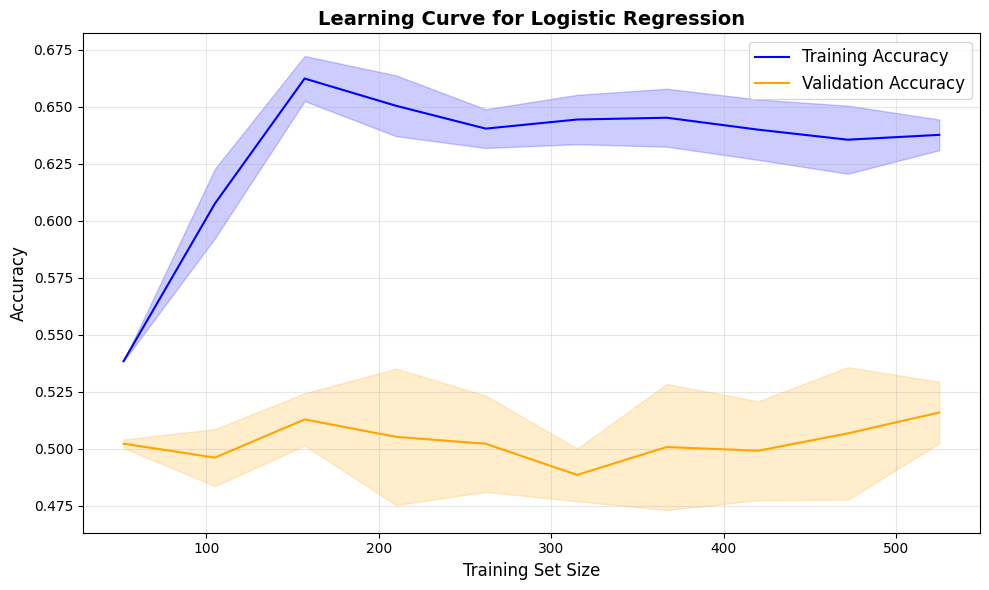

In [22]:
# Learning Curve for Logistic Regression
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_logistic_model,  # Use the best model from GridSearchCV
    X=X_train_scaled,  # Training features
    y=y_train,  # Training labels
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fraction of training data
    n_jobs=-1,  # Use all processors
    random_state=42
)

# Calculate mean and standard deviation of training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

# Customize the plot
plt.title('Learning Curve for Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Naive Bayes Model**

In [25]:
# Define parameter grid for Naive Bayes
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6],  # For GaussianNB (controls variance smoothing)
}

# Initialize Naive Bayes model
naive_bayes_model = GaussianNB()

# Set up GridSearchCV
grid_search_nb = GridSearchCV(
    estimator=naive_bayes_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV on training data
grid_search_nb.fit(X_train, y_train)

# Display the best parameters
print("Best Parameters for Naive Bayes:", grid_search_nb.best_params_)

# Use the best model for evaluation
best_nb_model = grid_search_nb.best_estimator_

# Evaluate on validation set
y_val_pred = best_nb_model.predict(X_val)
print("Validation Accuracy for Naive Bayes:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report for Naive Bayes:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_nb_model.predict(X_test)
print("Test Accuracy for Naive Bayes:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report for Naive Bayes:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters for Naive Bayes: {'var_smoothing': 1e-09}
Validation Accuracy for Naive Bayes: 0.4611872146118721
Validation Classification Report for Naive Bayes:
              precision    recall  f1-score   support

        Loss       0.46      0.82      0.59       104
         Win       0.46      0.14      0.21       115

    accuracy                           0.46       219
   macro avg       0.46      0.48      0.40       219
weighted avg       0.46      0.46      0.39       219

Test Accuracy for Naive Bayes: 0.5205479452054794
Test Classification Report for Naive Bayes:
              precision    recall  f1-score   support

        Loss       0.51      0.83      0.63       107
         Win       0.58      0.22      0.32       112

    accuracy                           0.52       219
   macro avg       0.54      0.53      0.48       219
weighted avg       0.54      0.52      0.47       219



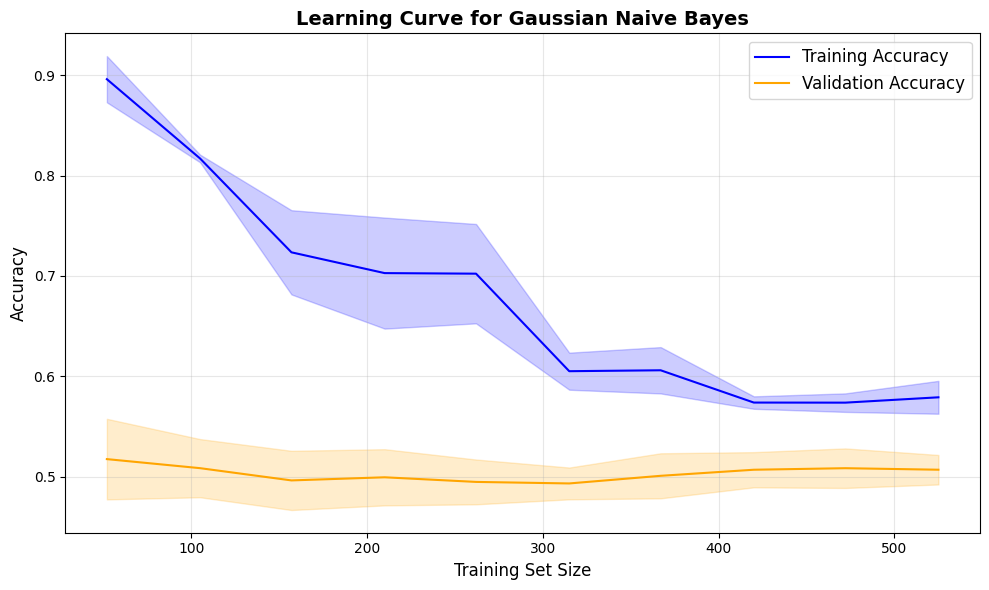

In [27]:
# Initialize Gaussian Naive Bayes model
gnb_model = GaussianNB(var_smoothing=1e-09)

# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=gnb_model,
    X=X_train,  # Use training features
    y=y_train,  # Use training labels
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    train_sizes=np.linspace(0.1, 1.0, 10),  # Training set size fractions
    n_jobs=-1
)

# Calculate mean and standard deviation of training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

# Customize the plot
plt.title('Learning Curve for Gaussian Naive Bayes', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# **Research Question 2: Role of Powerplay Performance in Determining Match Outcome**

**Random Forest Model**

In [28]:
# Load deliveries data and filter for powerplay
powerplay_deliveries = deliveries_df[deliveries_df['over'] <= 6]

# Calculate powerplay stats per match and team
powerplay_stats = powerplay_deliveries.groupby(['match_id', 'batting_team']).agg(
    powerplay_runs=('total_runs', 'sum'),
    powerplay_wickets=('is_wicket', 'sum')
).reset_index()

# Merge powerplay stats with match outcomes
matches_df = pd.merge(matches_df, powerplay_stats, left_on=['id', 'team1'], right_on=['match_id', 'batting_team'], how='left')
matches_df['match_result'] = matches_df['winner'] == matches_df['team1']

# Define features and target
X = matches_df[['powerplay_runs', 'powerplay_wickets']].fillna(0)  # Handle missing values
y = matches_df['match_result'].astype(int)

# Split data into train, validation, and test sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [29]:
# Define parameter grid for Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2'],  # Number of features considered for splitting
}

# Initialize Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit Grid Search on training data
grid_search.fit(X_train, y_train)

# Best parameters and estimator
print("Best Parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# Evaluate on validation set
y_val_pred = best_rf_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_rf_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))


Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Validation Accuracy: 0.5616438356164384
Validation Classification Report:
              precision    recall  f1-score   support

        Loss       0.58      0.50      0.54       112
         Win       0.54      0.63      0.58       107

    accuracy                           0.56       219
   macro avg       0.56      0.56      0.56       219
weighted avg       0.56      0.56      0.56       219

Test Accuracy: 0.6164383561643836
Test Classification Report:
              precision    recall  f1-score   support

        Loss       0.57      0.61      0.59        98
         Win       0.66      0.62      0.64       121

    accuracy                           0.62       219
   macro avg       0.61      0.62      0.61       219
weighted avg       0.62      0.62      0.62       219



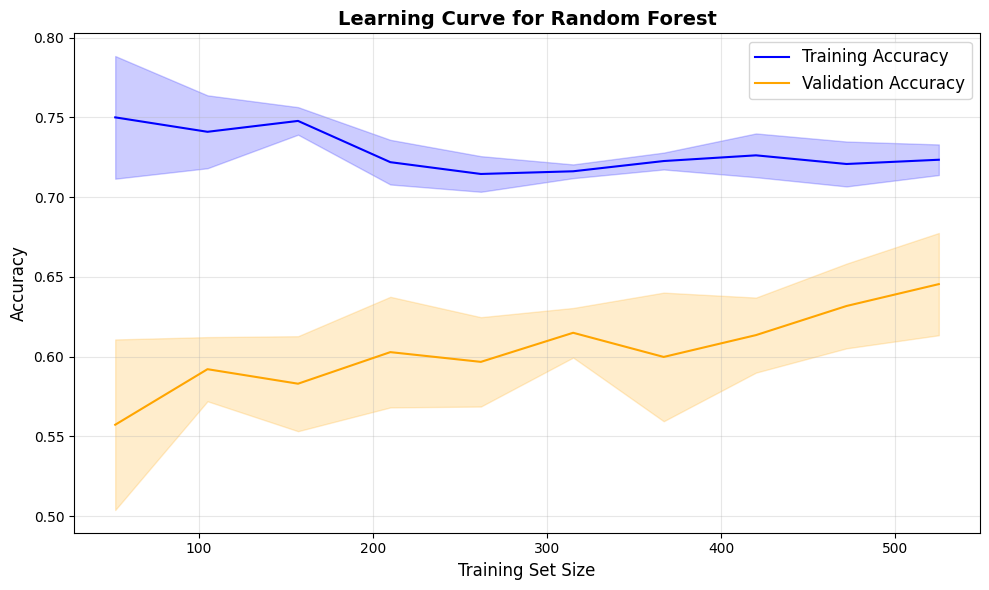

In [30]:
# Generate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf_model,  # Using the best model
    X=X_train,  # Training features
    y=y_train,  # Training labels
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fractions of training data
    n_jobs=-1
)

# Calculate mean and standard deviation of training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

# Customize the plot
plt.title('Learning Curve for Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Logistic Regression**

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters: {'C': 0.01, 'l1_ratio': 0.5, 'max_iter': 200, 'penalty': 'elasticnet', 'solver': 'saga'}
Validation Accuracy: 0.6118721461187214
Validation Classification Report:
              precision    recall  f1-score   support

        Loss       0.66      0.51      0.57       112
         Win       0.58      0.72      0.64       107

    accuracy                           0.61       219
   macro avg       0.62      0.61      0.61       219
weighted avg       0.62      0.61      0.61       219

Test Accuracy: 0.6529680365296804
Test Classification Report:
              precision    recall  f1-score   support

        Loss       0.62      0.58      0.60        98
         Win       0.68      0.71      0.69       121

    accuracy                           0.65       219
   macro avg       0.65      0.65      0.65       219
weighted avg       0.65      0.65      0.65       219



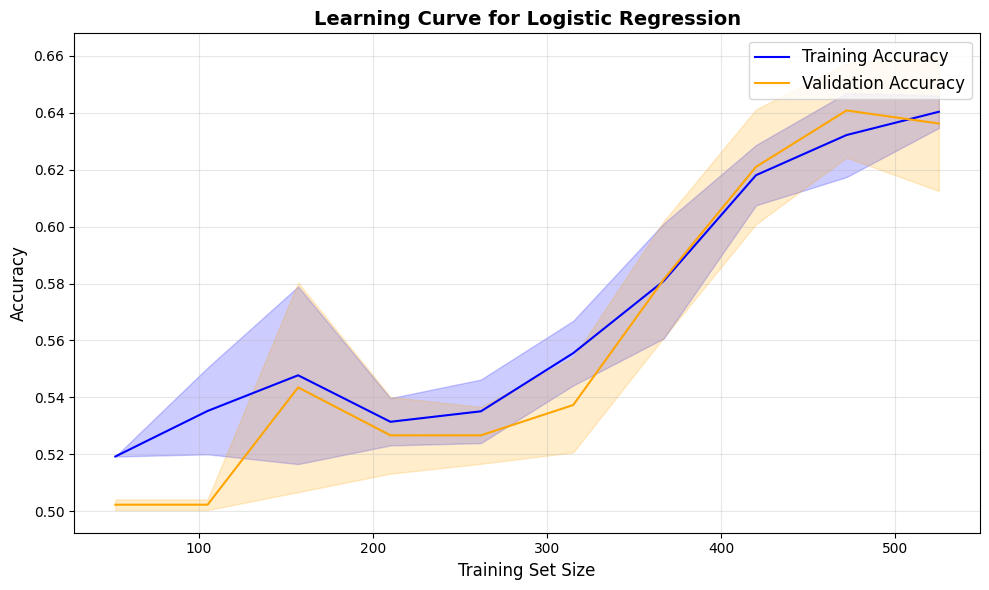

In [31]:
# Define parameter grid for Logistic Regression
param_grid = [
    {
        'penalty': ['l1'],  # L1 requires specific solvers
        'solver': ['liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 200, 500]
    },
    {
        'penalty': ['l2'],  # L2 is widely supported
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'max_iter': [100, 200, 500]
    },
    {
        'penalty': ['elasticnet'],  # ElasticNet requires l1_ratio and saga solver
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10, 100],
        'l1_ratio': [0.1, 0.5, 0.9],
        'max_iter': [100, 200, 500]
    }
]

# Initialize Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV on training data
grid_search.fit(X_train, y_train)

# Best parameters and estimator
print("Best Parameters:", grid_search.best_params_)
best_logistic_model = grid_search.best_estimator_

# Evaluate on validation set
y_val_pred = best_logistic_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_logistic_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))

# Generate learning curve for Logistic Regression
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_logistic_model,
    X=X_train,  # Training features
    y=y_train,  # Training labels
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fractions of training data
    n_jobs=-1
)

# Calculate mean and standard deviation of training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

# Customize the plot
plt.title('Learning Curve for Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Naive Bayes Model**

In [32]:
# Define parameter grid for Gaussian Naive Bayes
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]  # Variance smoothing parameter
}

# Initialize Gaussian Naive Bayes model
naive_bayes_model = GaussianNB()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=naive_bayes_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit Grid Search on training data
grid_search.fit(X_train, y_train)

# Best parameters and estimator
print("Best Parameters for Naive Bayes:", grid_search.best_params_)
best_nb_model = grid_search.best_estimator_

# Evaluate on validation set
y_val_pred = best_nb_model.predict(X_val)
print("Validation Accuracy for Naive Bayes:", accuracy_score(y_val, y_val_pred))
print("Validation Classification Report for Naive Bayes:")
print(classification_report(y_val, y_val_pred, target_names=['Loss', 'Win']))

# Final evaluation on test set
y_test_pred = best_nb_model.predict(X_test)
print("Test Accuracy for Naive Bayes:", accuracy_score(y_test, y_test_pred))
print("Test Classification Report for Naive Bayes:")
print(classification_report(y_test, y_test_pred, target_names=['Loss', 'Win']))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters for Naive Bayes: {'var_smoothing': 1e-09}
Validation Accuracy for Naive Bayes: 0.6073059360730594
Validation Classification Report for Naive Bayes:
              precision    recall  f1-score   support

        Loss       0.64      0.52      0.57       112
         Win       0.58      0.70      0.64       107

    accuracy                           0.61       219
   macro avg       0.61      0.61      0.60       219
weighted avg       0.61      0.61      0.60       219

Test Accuracy for Naive Bayes: 0.634703196347032
Test Classification Report for Naive Bayes:
              precision    recall  f1-score   support

        Loss       0.59      0.59      0.59        98
         Win       0.67      0.67      0.67       121

    accuracy                           0.63       219
   macro avg       0.63      0.63      0.63       219
weighted avg       0.63      0.63      0.63       219



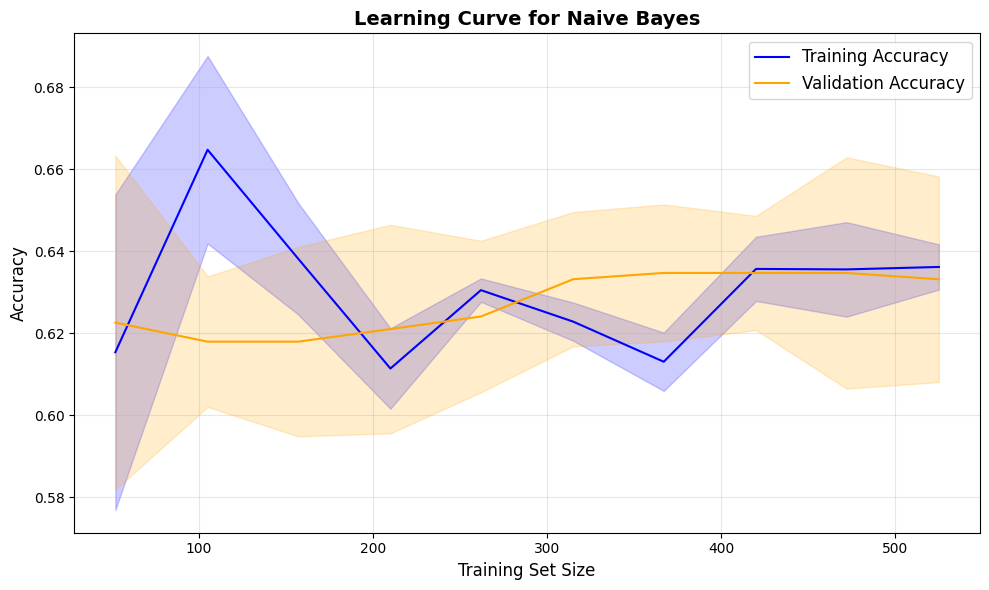

In [34]:
# Generate learning curve for Naive Bayes
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_nb_model,  # Use the best model from GridSearchCV
    X=X_train,  # Training features
    y=y_train,  # Training labels
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluation metric
    train_sizes=np.linspace(0.1, 1.0, 10),  # Fractions of training data
    n_jobs=-1
)

# Calculate mean and standard deviation of training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='Orange')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='Orange')

# Customize the plot
plt.title('Learning Curve for Naive Bayes', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# **Research Question 3: Influence of Individual Performance Metrics on Player of the Match**

Random Forest Model

In [39]:
# Step 1: Aggregate Batting Stats
batting_stats = deliveries_df.groupby(['match_id', 'batter']).agg(
    runs_scored=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()
batting_stats['strike_rate'] = (batting_stats['runs_scored'] / batting_stats['balls_faced']) * 100

# Step 2: Aggregate Bowling Stats
bowling_stats = deliveries_df.groupby(['match_id', 'bowler']).agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count'),
    wickets_taken=('is_wicket', 'sum')
).reset_index()
bowling_stats['economy_rate'] = (bowling_stats['runs_conceded'] / bowling_stats['balls_bowled']) * 6

# Step 3: Create list of Player of the Match
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'batter'})

# Step 4: Merge Batting Stats with Player of the Match Data
batting_award = pd.merge(batting_stats, award_winners, on=['match_id', 'batter'], how='left', indicator=True)
batting_award['won_award'] = (batting_award['_merge'] == 'both').astype(int)
batting_award = batting_award.rename(columns={'batter': 'player'}).drop(columns=['_merge'])

# Step 5: Merge Bowling Stats with Player of the Match Data
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'bowler'})
bowling_award = pd.merge(bowling_stats, award_winners, on=['match_id', 'bowler'], how='left', indicator=True)
bowling_award['won_award'] = (bowling_award['_merge'] == 'both').astype(int)
bowling_award = bowling_award.rename(columns={'bowler': 'player'}).drop(columns=['_merge'])

# Step 6: Concatenate Batting and Bowling Data
combined_stats = pd.concat([batting_award[['match_id', 'player', 'runs_scored', 'strike_rate', 'won_award']],
                            bowling_award[['match_id', 'player', 'wickets_taken', 'economy_rate', 'won_award']]],
                           axis=0, ignore_index=True).fillna(0)

# Step 7: Define Features and Target Variable
X = combined_stats[['runs_scored', 'strike_rate', 'wickets_taken', 'economy_rate']]
y = combined_stats['won_award']

# Check the class distribution before splitting
print("Class distribution in the target variable (won_award) before splitting:")
print(y.value_counts())

# Step 8: Split the data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Check the class distribution in the training and test sets after splitting
print("\nClass distribution in y_train after splitting:")
print(y_train.value_counts())
print("\nClass distribution in y_test after splitting:")
print(y_test.value_counts())

# Step 9: Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Check the class distribution after applying SMOTE
print("\nClass distribution in y_train after applying SMOTE:")
print(y_resampled.value_counts())

# Step 10: Grid Search with Cross-Validation for Random Forest Model
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_resampled, y_resampled)

# Best Parameters from Grid Search
print("Best Parameters from Grid Search:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

# Step 11: Make Predictions and Evaluate the Model
y_pred = best_rf_model.predict(X_test)
y_proba = best_rf_model.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Award', 'Won Award']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.2f}")


Class distribution in the target variable (won_award) before splitting:
won_award
0    28121
1     1372
Name: count, dtype: int64

Class distribution in y_train after splitting:
won_award
0    19685
1      960
Name: count, dtype: int64

Class distribution in y_test after splitting:
won_award
0    8436
1     412
Name: count, dtype: int64

Class distribution in y_train after applying SMOTE:
won_award
0    19685
1    19685
Name: count, dtype: int64
Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters from Grid Search: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Accuracy: 0.92

Confusion Matrix:
[[7932  504]
 [ 240  172]]

Classification Report:
              precision    recall  f1-score   support

    No Award       0.97      0.94      0.96      8436
   Won Award       0.25      0.42      0.32       412

    accuracy                           0.92      8848
   macro avg       0.61      0.68      0.64      8848
weighted avg       0.94      0.92      0.93      8848


ROC-AUC Score: 0.79


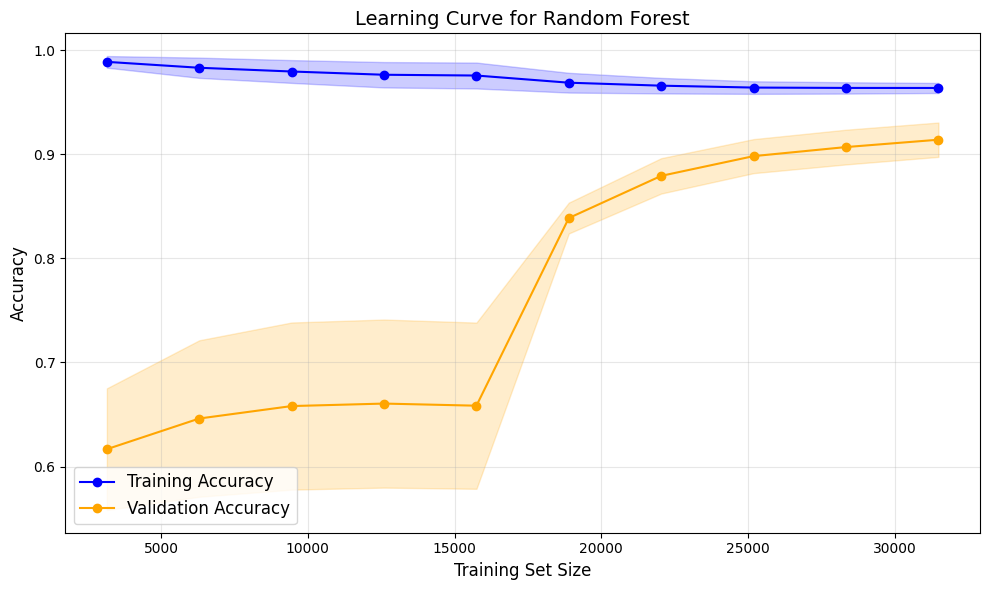

In [40]:
# Step 12: Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf_model,  # Best model from grid search
    X=X_resampled,           # Use the resampled training data
    y=y_resampled,
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),  # Training set sizes
    n_jobs=-1                # Use all processors
)

# Calculate mean and standard deviation for training and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange', marker='o')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

# Add labels, title, and legend
plt.title('Learning Curve for Random Forest', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Logistic Regression**

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Validation Accuracy (Logistic Regression): 0.8042041023902357

Classification Report (Validation):
              precision    recall  f1-score   support

    No Award       0.99      0.81      0.89      5624
   Won Award       0.16      0.78      0.27       275

    accuracy                           0.80      5899
   macro avg       0.58      0.79      0.58      5899
weighted avg       0.95      0.80      0.86      5899


Test Accuracy (Logistic Regression): 0.7967452110527208

Classification Report (Test):
              precision    recall  f1-score   support

    No Award       0.99      0.80      0.88      5625
   Won Award       0.16      0.81      0.27       274

    accuracy                           0.80      5899
   macro avg       0.58      0.80      0.58      5899
weighted avg       0.95      0.80      0.85      5899


ROC-AUC Score (Logistic Regression): 0.85


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 clas

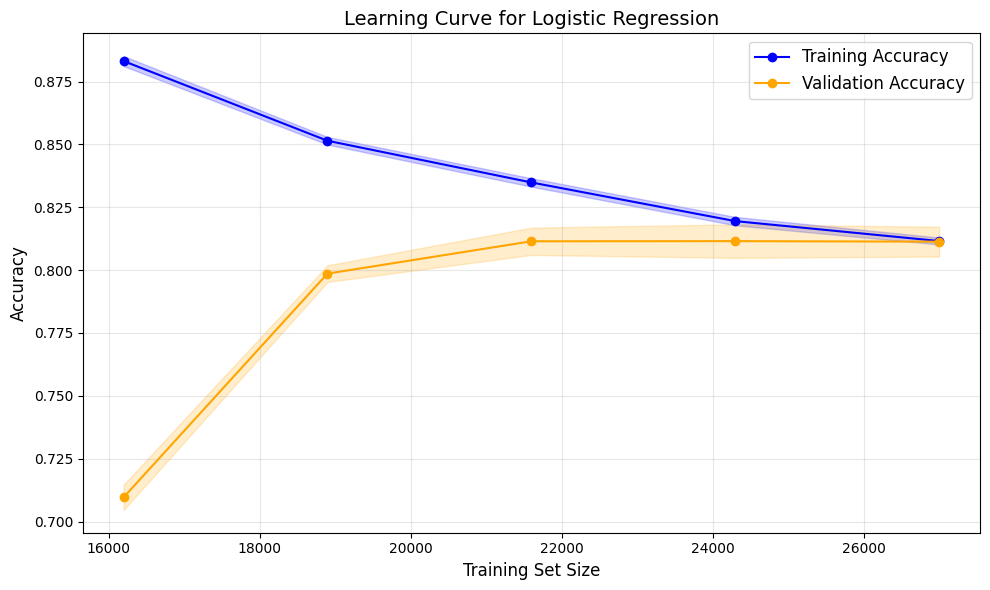

In [45]:
# Step 1: Aggregate Batting Stats
batting_stats = deliveries_df.groupby(['match_id', 'batter']).agg(
    runs_scored=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()
batting_stats['strike_rate'] = (batting_stats['runs_scored'] / batting_stats['balls_faced']) * 100

# Step 2: Aggregate Bowling Stats
bowling_stats = deliveries_df.groupby(['match_id', 'bowler']).agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count'),
    wickets_taken=('is_wicket', 'sum')
).reset_index()
bowling_stats['economy_rate'] = (bowling_stats['runs_conceded'] / bowling_stats['balls_bowled']) * 6

# Step 3: Create Player of the Match Data
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'batter'})

# Step 4: Merge Batting Stats with Player of the Match Data
batting_award = pd.merge(batting_stats, award_winners, on=['match_id', 'batter'], how='left', indicator=True)
batting_award['won_award'] = (batting_award['_merge'] == 'both').astype(int)
batting_award = batting_award.rename(columns={'batter': 'player'}).drop(columns=['_merge'])

# Step 5: Merge Bowling Stats with Player of the Match Data
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'bowler'})
bowling_award = pd.merge(bowling_stats, award_winners, on=['match_id', 'bowler'], how='left', indicator=True)
bowling_award['won_award'] = (bowling_award['_merge'] == 'both').astype(int)
bowling_award = bowling_award.rename(columns={'bowler': 'player'}).drop(columns=['_merge'])

# Step 6: Combine Batting and Bowling Data
combined_stats = pd.concat([batting_award[['match_id', 'player', 'runs_scored', 'strike_rate', 'won_award']],
                            bowling_award[['match_id', 'player', 'wickets_taken', 'economy_rate', 'won_award']]],
                           axis=0, ignore_index=True).fillna(0)

# Step 7: Define Features and Target Variable
X = combined_stats[['runs_scored', 'strike_rate', 'wickets_taken', 'economy_rate']]
y = combined_stats['won_award']

# Step 8: Split Data into Train, Validation, and Test Sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Step 9: Apply SMOTE to Handle Class Imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Step 10: Define Parameter Grid for Grid Search
param_grid_lr = {
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs'],
    'max_iter': [100, 200, 500]
}

# Step 11: Initialize Logistic Regression and Perform Grid Search
lr_model = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
grid_search_lr.fit(X_resampled, y_resampled)
best_lr_model = grid_search_lr.best_estimator_

# Step 12: Validation Performance
y_val_pred_lr = best_lr_model.predict(X_val)
print("\nValidation Accuracy (Logistic Regression):", accuracy_score(y_val, y_val_pred_lr))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_lr, target_names=['No Award', 'Won Award']))

# Step 13: Test Performance
y_test_pred_lr = best_lr_model.predict(X_test)
y_test_proba_lr = best_lr_model.predict_proba(X_test)[:, 1]
print("\nTest Accuracy (Logistic Regression):", accuracy_score(y_test, y_test_pred_lr))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_lr, target_names=['No Award', 'Won Award']))

# ROC-AUC Score
roc_auc_lr = roc_auc_score(y_test, y_test_proba_lr)
print(f"\nROC-AUC Score (Logistic Regression): {roc_auc_lr:.2f}")

# Step 14: Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_lr_model,
    X=X_resampled,
    y=y_resampled,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange', marker='o')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve for Logistic Regression', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Naive Bayes**


Validation Accuracy (Naive Bayes): 0.8401423970164434

Classification Report (Validation):
              precision    recall  f1-score   support

    No Award       0.98      0.85      0.91      5624
   Won Award       0.18      0.70      0.29       275

    accuracy                           0.84      5899
   macro avg       0.58      0.77      0.60      5899
weighted avg       0.95      0.84      0.88      5899


Test Accuracy (Naive Bayes): 0.8330225461942702

Classification Report (Test):
              precision    recall  f1-score   support

    No Award       0.98      0.84      0.91      5625
   Won Award       0.18      0.72      0.29       274

    accuracy                           0.83      5899
   macro avg       0.58      0.78      0.60      5899
weighted avg       0.95      0.83      0.88      5899


ROC-AUC Score (Naive Bayes): 0.84


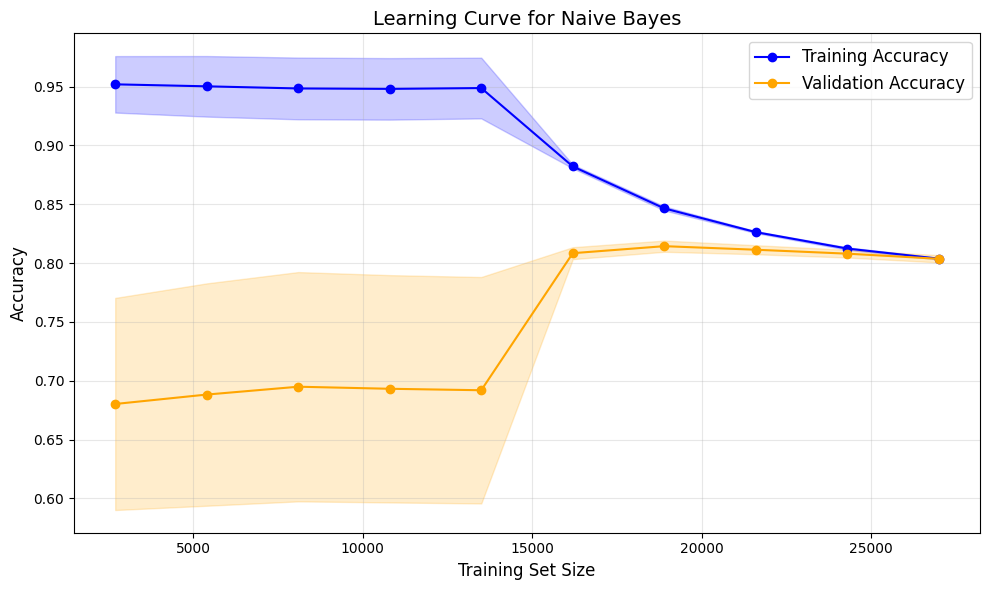

In [46]:
# Step 1: Aggregate Batting Stats
batting_stats = deliveries_df.groupby(['match_id', 'batter']).agg(
    runs_scored=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()
batting_stats['strike_rate'] = (batting_stats['runs_scored'] / batting_stats['balls_faced']) * 100

# Step 2: Aggregate Bowling Stats
bowling_stats = deliveries_df.groupby(['match_id', 'bowler']).agg(
    runs_conceded=('total_runs', 'sum'),
    balls_bowled=('ball', 'count'),
    wickets_taken=('is_wicket', 'sum')
).reset_index()
bowling_stats['economy_rate'] = (bowling_stats['runs_conceded'] / bowling_stats['balls_bowled']) * 6

# Step 3: Create Player of the Match Data
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'batter'})

# Step 4: Merge Batting Stats with Player of the Match Data
batting_award = pd.merge(batting_stats, award_winners, on=['match_id', 'batter'], how='left', indicator=True)
batting_award['won_award'] = (batting_award['_merge'] == 'both').astype(int)
batting_award = batting_award.rename(columns={'batter': 'player'}).drop(columns=['_merge'])

# Step 5: Merge Bowling Stats with Player of the Match Data
award_winners = matches_df[['id', 'player_of_match']].rename(columns={'id': 'match_id', 'player_of_match': 'bowler'})
bowling_award = pd.merge(bowling_stats, award_winners, on=['match_id', 'bowler'], how='left', indicator=True)
bowling_award['won_award'] = (bowling_award['_merge'] == 'both').astype(int)
bowling_award = bowling_award.rename(columns={'bowler': 'player'}).drop(columns=['_merge'])

# Step 6: Combine Batting and Bowling Data
combined_stats = pd.concat([batting_award[['match_id', 'player', 'runs_scored', 'strike_rate', 'won_award']],
                            bowling_award[['match_id', 'player', 'wickets_taken', 'economy_rate', 'won_award']]],
                           axis=0, ignore_index=True).fillna(0)

# Step 7: Define Features and Target Variable
X = combined_stats[['runs_scored', 'strike_rate', 'wickets_taken', 'economy_rate']]
y = combined_stats['won_award']

# Step 8: Split Data into Train, Validation, and Test Sets
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Step 9: Apply SMOTE to Handle Class Imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Step 10: Initialize Naive Bayes Model
nb_model = GaussianNB()

# Step 11: Train Naive Bayes on Resampled Training Data
nb_model.fit(X_resampled, y_resampled)

# Step 12: Validation Performance
y_val_pred_nb = nb_model.predict(X_val)
print("\nValidation Accuracy (Naive Bayes):", accuracy_score(y_val, y_val_pred_nb))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred_nb, target_names=['No Award', 'Won Award']))

# Step 13: Test Performance
y_test_pred_nb = nb_model.predict(X_test)
y_test_proba_nb = nb_model.predict_proba(X_test)[:, 1]
print("\nTest Accuracy (Naive Bayes):", accuracy_score(y_test, y_test_pred_nb))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_nb, target_names=['No Award', 'Won Award']))

# ROC-AUC Score
roc_auc_nb = roc_auc_score(y_test, y_test_proba_nb)
print(f"\nROC-AUC Score (Naive Bayes): {roc_auc_nb:.2f}")

# Step 14: Plot Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=nb_model,
    X=X_resampled,
    y=y_resampled,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='blue')
plt.plot(train_sizes, val_scores_mean, label='Validation Accuracy', color='orange', marker='o')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='orange')

plt.title('Learning Curve for Naive Bayes', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
